#### Stein Variational Gradient Descent
+ This notebook is for Stein Variational Inference:
+ target posterior $p(w|x^n)$ is approximated by $q(w)$ based on Stein Discrepancy $D(p, q)$:
$$
D(p, q) := \max_{\phi \in F} E_{w \sim q} [tr(A_{p}\phi(w))],
$$
+ where $A_p$ is stein's operator: $A_{p} \phi(w) = \nabla_w \log p^T(w|x^n) \phi(w) + \nabla_w \phi(w)$.
+ When $F$ is RKHS on $d$-dimensional, and the approximated distribution is $q(z)$, where $z = T(x) = x + \epsilon \phi(x)$,
+ then the the maximum direction $\phi^*_{q,p}$ of $\frac{d}{d\epsilon}KL(q|p) |_{\epsilon=0}$ is given by 
$$
\phi^*_{q,p}(\cdot) = E_{w \sim q} [tr(A_p k(w,\cdot))] \approx \sum_{l=1}^L \frac{1}{L} \Bigl\{ \nabla_w \log p(w_l|x^n) k(w_l,\cdot) + \nabla_w k(w_l, \cdot) \Bigr\}
$$

+ Based on the value, the sample of the posterior distribution $w^{(l)}$ is calculated iteratively:
$$
w^{(l+1)} = w^{(l)} + \epsilon \phi^*{q,p}(w^{(l)})
$$
+ where $\epsilon$ is step size, and should be gradually descreased like conventional gradient descent method.

# First Step
+ Check Algorithm by simple case
+ Here, we consider about a posterior for mean of multivariate gaussian distribution:
$$
p(w|x^n) \propto p(\mu) \prod_{i=1}^n N(x_i|\mu, I_M)
$$

In [1]:
%matplotlib inline

In [2]:
import numpy as np
from scipy.spatial.distance import pdist, squareform
import matplotlib.pyplot as plt

/home/fumish/.conda/envs/gpu/lib/python3.9/site-packages/scipy/__init__.py:155: UserWarning: A NumPy version >=1.18.5 and <1.26.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


## Data Generation

In [22]:
## dimension of input
M = 2

# number of samples
n = 50

data_seed = 20241229
np.random.seed(data_seed)

true_mu = np.array([-10, 10])
train_X = np.random.multivariate_normal(true_mu, np.eye(M), size=n)

## Hyperparameters
+ kernel function: Radial Basis Kernel $\exp(-\|x - y\|^2 / 2h^2)$
+ prior: multivariate distribution $N(\mu|0, \beta^{-1} I_M)$
+ initial samples: $w \sim q_0(w)$, where $w \in R^{L \times M}$, $L$ is the number of sample from the approximated posterior

In [23]:
ln_seed = 20241231
np.random.seed(ln_seed)

pri_beta = 1

L = 100
initial_post_param = np.random.normal(size = (L, M))

h = 1
first_step_size = 0.05

### Calculate gradient of first update
+ Note: In the algorithm, $\sum_i \nabla_{w_i} k(w_i, w_j)$ is necessary, and the result is $L \times M$.

In [24]:
# ite = 0

# post_param = initial_post_param.copy()

# # radial basis kernel is used here
# h = 1
# kernel_post = np.exp(-squareform(pdist(post_param))/(2*h**2))

# dw_kernel_post = (-kernel_post.T @ post_param + kernel_post.sum(axis=0)[:,np.newaxis] * post_param) / (h**2)

# # debug
# target = np.zeros((L, M))
# for j in range(L):
#     for k in range(M):
#         target[j,k] = (-post_param[:,k]*kernel_post[:,j] + post_param[j,k]*kernel_post[:,j]).sum() / (h**2)
#         pass

# # gradient of log posterior
# dw_logp = (train_X.sum(axis=0)[np.newaxis,:] - (n + 1/pri_beta)*post_param)

# # gradient of target functional
# phi_post_param = (dw_logp + dw_kernel_post) / L

# plt.scatter(post_param[:,0], post_param[:,1])
# plt.show()

# plt.scatter(phi_post_param[:,0], phi_post_param[:,1])
# plt.show()

## Original method
+ Here, we simply use the algorithm

In [27]:
n_ite = 5000
post_param = initial_post_param.copy()

disp_cycle = 100

h = 1
for ite in range(n_ite):
    dist = pdist(post_param)
    
    # radial basis kernel is used here
    kernel_post = np.exp(-squareform(dist)/(2*h**2))

    # gradient of kernel function
    dw_kernel_post = (-kernel_post.T @ post_param + kernel_post.sum(axis=0)[:,np.newaxis] * post_param) / (h**2)
    
    # gradient of log posterior
    dw_logp = (train_X.sum(axis=0)[np.newaxis,:] - (n + 1/pri_beta)*post_param)
    
    # gradient of target functional
    phi_post_param = (kernel_post.T @ dw_logp + dw_kernel_post) / L

    # sample update
    # step_size = first_step_size / (ite + 1)
    step_size = first_step_size
    post_param = post_param + step_size * phi_post_param

    if ite % disp_cycle == 0:
        print("ite = {}, post_param = {}, h = {}".format(ite, post_param[0], h))
    pass

ite = 0, post_param = [-13.05437764  12.43919658], h = 1
ite = 100, post_param = [-6.97793431  6.7018309 ], h = 1
ite = 200, post_param = [-6.39321414  5.98399581], h = 1
ite = 300, post_param = [-6.48983702  6.07339665], h = 1
ite = 400, post_param = [-7.0108683   6.64747536], h = 1
ite = 500, post_param = [-6.72076068  6.30296681], h = 1
ite = 600, post_param = [-7.13753869  6.82424792], h = 1
ite = 700, post_param = [-5.53325714  5.10761069], h = 1
ite = 800, post_param = [-6.55265108  6.27480809], h = 1
ite = 900, post_param = [-5.96262462  5.63719678], h = 1
ite = 1000, post_param = [-7.78826598  7.72809304], h = 1
ite = 1100, post_param = [-7.26132282  7.15563662], h = 1
ite = 1200, post_param = [-5.17851931  4.84451198], h = 1
ite = 1300, post_param = [-6.78815425  6.60064144], h = 1
ite = 1400, post_param = [-7.35059399  7.27531156], h = 1
ite = 1500, post_param = [-5.91804597  5.68907084], h = 1
ite = 1600, post_param = [-4.21702207  3.78379102], h = 1
ite = 1700, post_param =

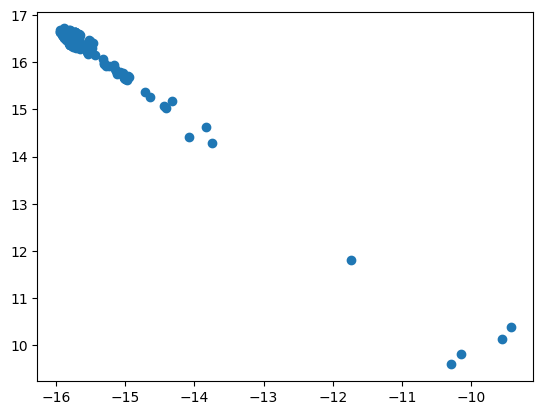

In [28]:
plt.scatter(post_param[:,0], post_param[:,1])
plt.show()

## Plus RMSProp
+ We utilize the RMSProp to adjust step size of the functional gradient

In [29]:
n_ite = 5000
post_param = initial_post_param.copy()

disp_cycle = 100

alpha = 0.9
# step_size = 1e-2
jitter = 1e-6
r_t = 0
for ite in range(n_ite):
    dist = pdist(post_param)
    h = np.sqrt(0.5*np.median(dist)**2/np.log(L))
    
    # radial basis kernel is used here
    kernel_post = np.exp(-squareform(dist)/(2*h**2))

    # gradient of kernel function
    dw_kernel_post = (-kernel_post.T @ post_param + kernel_post.sum(axis=0)[:,np.newaxis] * post_param) / (h**2)
    
    # gradient of log posterior
    dw_logp = (train_X.sum(axis=0)[np.newaxis,:] - (n + 1/pri_beta)*post_param)
    
    # gradient of target functional
    phi_post_param = (kernel_post.T @ dw_logp + dw_kernel_post) / L

    # sample update
    if ite == 0:
        r_t = phi_post_param**2
    else:    
        r_t = alpha * r_t + (1 - alpha) * phi_post_param**2
    
    # step_size = first_step_size / (ite + 1)
    # step_size = first_step_size
    step_size = first_step_size / np.sqrt(r_t + jitter)
    post_param = post_param + step_size * phi_post_param

    if ite % disp_cycle == 0:
        print("ite = {}, post_param = {}, h = {}, eta_t = {}".format(ite, post_param[0], h, step_size[0]))
    pass

ite = 0, post_param = [-0.58587376 -0.57252822], h = 0.5536466526065975, eta_t = [0.00064051 0.00059574]
ite = 100, post_param = [-5.28694597  4.15565149], h = 0.5424972821229253, eta_t = [0.00121221 0.00106653]
ite = 200, post_param = [-9.26919431  8.36740954], h = 0.4366975558244386, eta_t = [0.0082884  0.00507044]
ite = 300, post_param = [-9.6582869   9.77411684], h = 0.0019561762286901033, eta_t = [1.43217702 0.55820046]
ite = 400, post_param = [-9.67837542  9.74884863], h = 0.013849020028746117, eta_t = [4.52760618 4.50249449]
ite = 500, post_param = [-9.68372237  9.7560557 ], h = 0.014129641724107831, eta_t = [4.26030249 4.29566025]
ite = 600, post_param = [-9.6248029   9.78993121], h = 0.016792811781579677, eta_t = [3.58067364 3.80717795]
ite = 700, post_param = [-9.63346625  9.76106117], h = 0.015269433794073502, eta_t = [4.45420408 3.89402186]
ite = 800, post_param = [-9.64109255  9.78353346], h = 0.01387266799334123, eta_t = [4.05400653 3.472442  ]
ite = 900, post_param = [-9

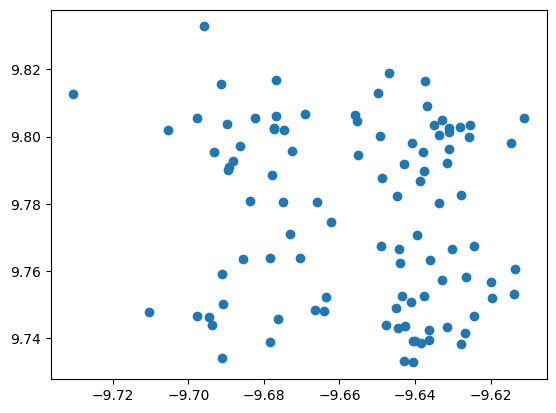

In [30]:
plt.scatter(post_param[:,0], post_param[:,1])
plt.show()

# Next Step: Logistic regression
+ Next we consider about logistic regression
+ Basically, it is same calculation except for derivative of log posterior

In [31]:
from scipy.special import expit

## Data Generation

In [32]:
## dimension of input
M = 5

# number of samples
n = 200

data_seed = 20241229
np.random.seed(data_seed)

true_w = np.random.normal(size=M)

train_X = np.random.normal(size=(n,M))
train_Y = np.random.binomial(1, expit(train_X @ true_w))

## Hyperparameters
+ kernel function: Radial Basis Kernel $\exp(-\|x - y\|^2 / 2h^2)$
+ prior: multivariate distribution $N(\mu|0, \beta^{-1} I_M)$
+ initial samples: $w \sim q_0(w)$, where $w \in R^{L \times M}$, $L$ is the number of sample from the approximated posterior

In [33]:
ln_seed = 20241231
np.random.seed(ln_seed)

pri_beta = 1

L = 100
initial_post_param = np.random.normal(size = (L, M))

h = 1
first_step_size = 0.05

## Learning
+ Change a derivative part of the posterior

In [34]:
n_ite = 5000
post_param = initial_post_param.copy()

disp_cycle = 100

alpha = 0.9
# step_size = 1e-2
jitter = 1e-6
r_t = 0
for ite in range(n_ite):
    dist = pdist(post_param)
    h = np.sqrt(0.5*np.median(dist)**2/np.log(L))
    
    # radial basis kernel is used here
    kernel_post = np.exp(-squareform(dist)/(2*h**2))

    # gradient of kernel function
    dw_kernel_post = (-kernel_post.T @ post_param + kernel_post.sum(axis=0)[:,np.newaxis] * post_param) / (h**2)
    
    # gradient of log posterior
    dw_logp = (train_Y[np.newaxis,:]-expit(post_param @ train_X.T))@train_X - 1/pri_beta*post_param
    
    # gradient of target functional
    phi_post_param = (kernel_post.T @ dw_logp + dw_kernel_post) / L

    # sample update
    if ite == 0:
        r_t = phi_post_param**2
    else:    
        r_t = alpha * r_t + (1 - alpha) * phi_post_param**2
    
    # step_size = first_step_size / (ite + 1)
    # step_size = first_step_size
    step_size = first_step_size / np.sqrt(r_t + jitter)
    post_param = post_param + step_size * phi_post_param

    if ite % disp_cycle == 0:
        print("ite = {}, post_param = {}, h = {}, step_size = {}".format(ite, post_param[0], h, step_size[0]))
    pass

ite = 0, post_param = [-0.58587376 -0.67252822 -0.34739504 -1.74420196  0.11277141], h = 0.9732267476637254, step_size = [0.00428812 0.00586958 0.01877046 0.05295068 0.01872544]
ite = 100, post_param = [-2.10123005 -1.67825643 -0.82328005 -0.30603069  0.78946731], h = 0.13119482084764741, step_size = [0.28988293 0.55173601 2.94726893 4.14842775 2.52775539]
ite = 200, post_param = [-1.8822974  -1.54455347 -0.73135584 -0.31348272  0.73970759], h = 0.024666469917733014, step_size = [9.0989423  6.5880332  7.9764111  6.17769092 8.72299723]
ite = 300, post_param = [-1.88226727 -1.54078568 -0.72687508 -0.31287374  0.74244534], h = 0.025180721009875985, step_size = [8.79109522 6.16516341 8.45929274 6.20257369 9.40467928]
ite = 400, post_param = [-1.88407426 -1.54933361 -0.78926308 -0.32228466  0.68250677], h = 0.026157025847028722, step_size = [7.9501796  5.47104448 7.07964897 7.38544365 6.69600506]
ite = 500, post_param = [-1.88483424 -1.54918904 -0.78528778 -0.31236751  0.68718755], h = 0.02

In [35]:
expit(train_X @ true_w)[:10]

array([0.69784747, 0.59239709, 0.35291562, 0.22766592, 0.53774067,
       0.69643567, 0.29775171, 0.21469685, 0.07502492, 0.0505858 ])

In [36]:
expit(post_param @ train_X.T).mean(axis=0)[:10]

array([0.70521565, 0.66714917, 0.34389912, 0.23249403, 0.61378384,
       0.69689907, 0.25924598, 0.24699812, 0.05364621, 0.04933112])

In [38]:
true_w

array([-1.69021652, -1.50911208, -0.7582608 , -0.19483659,  0.55051277])

In [39]:
post_param.mean(axis=0)

array([-1.9052244 , -1.52675066, -0.75860331, -0.33409465,  0.71119251])

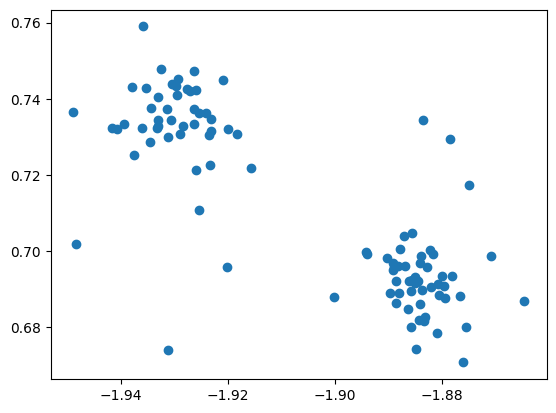

In [40]:
plt.scatter(post_param[:,0], post_param[:,4])
plt.show()

# Next Step: confirm the objective function is optimized
+ Stein Discrepancy $D(q, p)$ is
$$
D(q, p) = E_{w \sim q} [\nabla_w \log p(w)^T \phi(w) + \nabla_w \cdot \phi(w)]
$$
+ $phi(w)$ is obtained by the above alogorithm, and expected value is calculated by the samples from the approximated posterior.
+ Therefore, we can calculate the quantity.
+ Here, we consider about multivariate normal distribution as a target posterior.

## Data Generation

In [67]:
## dimension of input
M = 2

# number of samples
n = 50

data_seed = 20241229
np.random.seed(data_seed)

true_mu = np.array([-10, 10])
train_X = np.random.multivariate_normal(true_mu, np.eye(M), size=n)

## Hyperparameters
+ kernel function: Radial Basis Kernel $\exp(-\|x - y\|^2 / 2h^2)$
+ prior: multivariate distribution $N(\mu|0, \beta^{-1} I_M)$
+ initial samples: $w \sim q_0(w)$, where $w \in R^{L \times M}$, $L$ is the number of sample from the approximated posterior

In [68]:
ln_seed = 20241231
np.random.seed(ln_seed)

pri_beta = 2

L = 100
initial_post_param = np.random.normal(size = (L, M))

h = 1
first_step_size = 0.05

## Original method
+ Here, we simply use the algorithm

In [65]:
n_ite = 1000
post_param = initial_post_param.copy()

disp_cycle = 100

h = 1
for ite in range(n_ite):
    dist = pdist(post_param)
    
    # radial basis kernel is used here
    kernel_post = np.exp(-squareform(dist)/(2*h**2))

    # gradient of kernel function
    dw_kernel_post = (-kernel_post.T @ post_param + kernel_post.sum(axis=0)[:,np.newaxis] * post_param) / (h**2)
    
    # gradient of log posterior
    dw_logp = (train_X.sum(axis=0)[np.newaxis,:] - (n + 1/pri_beta)*post_param)
    
    # gradient of target functional
    phi_post_param = (kernel_post.T @ dw_logp + dw_kernel_post) / L

    # sample update
    # step_size = first_step_size / (ite + 1)
    step_size = first_step_size
    post_param = post_param + step_size * phi_post_param

    # calc stein discrepancy
    dw_partial_kernel = -2/h * (post_param[np.newaxis,:,:] - post_param[:,np.newaxis,:]) * kernel_post[:,:,np.newaxis]
    dwdw_kernel = (2/h * kernel_post[:,:,np.newaxis] * (1+(post_param[np.newaxis,:,:] - post_param[:,np.newaxis,:])**2/h))
    
    # divergence of phi
    div_phi = (dw_logp[np.newaxis,:,:] * dw_partial_kernel + dwdw_kernel).sum(axis=2).mean()

    if ite % disp_cycle == 0:
        print("ite = {}, post_param = {}, h = {}, div_phi = {}".format(ite, post_param[0], h, div_phi))
    pass

ite = 0, post_param = [-13.05660199  12.43739082], h = 1, div_phi = 79.38275363424115
ite = 100, post_param = [-7.23441441  7.00311182], h = 1, div_phi = -16.14953353148607
ite = 200, post_param = [-7.13807691  6.8397818 ], h = 1, div_phi = -5.331185241705943
ite = 300, post_param = [-7.25008263  6.98521189], h = 1, div_phi = -14.24317547745905
ite = 400, post_param = [-6.82567614  6.50638264], h = 1, div_phi = -17.054152923842867
ite = 500, post_param = [-7.23365646  6.97486106], h = 1, div_phi = -5.738976958858267
ite = 600, post_param = [-8.57824838  8.52183353], h = 1, div_phi = -8.463519303988123
ite = 700, post_param = [-4.87918518  4.4174193 ], h = 1, div_phi = -22.080600575196748
ite = 800, post_param = [-5.66915203  5.21680415], h = 1, div_phi = -2.4566878360297686
ite = 900, post_param = [-8.17193611  7.98726476], h = 1, div_phi = 5.969630167611674


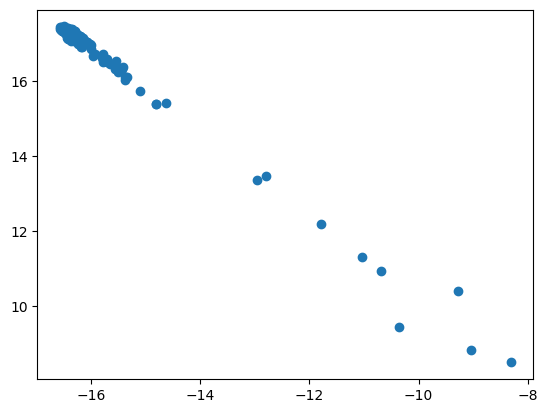

In [66]:
plt.scatter(post_param[:,0], post_param[:,1])
plt.show()

In [71]:
n_ite = 5000
post_param = initial_post_param.copy()

disp_cycle = 100

alpha = 0.9
# step_size = 1e-2
jitter = 1e-6
r_t = 0
for ite in range(n_ite):
    dist = pdist(post_param)
    h = np.sqrt(0.5*np.median(dist)**2/np.log(L))
    
    # radial basis kernel is used here
    kernel_post = np.exp(-squareform(dist)/(2*h**2))

    # gradient of kernel function
    dw_kernel_post = (-kernel_post.T @ post_param + kernel_post.sum(axis=0)[:,np.newaxis] * post_param) / (h**2)
    
    # gradient of log posterior
    dw_logp = (train_X.sum(axis=0)[np.newaxis,:] - (n + 1/pri_beta)*post_param)
    
    # gradient of target functional
    phi_post_param = (kernel_post.T @ dw_logp + dw_kernel_post) / L

    # sample update
    if ite == 0:
        r_t = phi_post_param**2
    else:    
        r_t = alpha * r_t + (1 - alpha) * phi_post_param**2
    
    # step_size = first_step_size / (ite + 1)
    # step_size = first_step_size
    step_size = first_step_size / np.sqrt(r_t + jitter)
    post_param = post_param + step_size * phi_post_param

    # calc stein discrepancy
    dw_partial_kernel = -2/h * (post_param[np.newaxis,:,:] - post_param[:,np.newaxis,:]) * kernel_post[:,:,np.newaxis]
    dwdw_kernel = (2/h * kernel_post[:,:,np.newaxis] * (1+(post_param[np.newaxis,:,:] - post_param[:,np.newaxis,:])**2/h))
    # divergence of phi
    div_phi = (dw_logp[np.newaxis,:,:] * dw_partial_kernel + dwdw_kernel).sum(axis=2).mean()
    dw_logp_phi = (dw_logp * phi_post_param).sum(axis=1).mean()
    stein_discrepancy = dw_logp_phi + div_phi
    
    if ite % disp_cycle == 0:
        print("ite = {}, post_param = {}, h = {}, eta_t = {}, stein_discrepancy = {}".format(ite, post_param[0], h, step_size[0], stein_discrepancy))
    pass

ite = 0, post_param = [-0.58587376 -0.57252822], h = 0.5536466526065975, eta_t = [0.00064028 0.0005959 ], stein_discrepancy = 67844.95124176481
ite = 100, post_param = [-5.29112798  4.1591469 ], h = 0.5428398273245817, eta_t = [0.00120147 0.00105917], stein_discrepancy = 17724.87306368966
ite = 200, post_param = [-9.31431234  8.39696765], h = 0.44570739266041265, eta_t = [0.00772773 0.00481831], stein_discrepancy = 519.6079933073052
ite = 300, post_param = [-9.75458903  9.87091963], h = 0.0028442306119940393, eta_t = [1.30116634 0.50682799], stein_discrepancy = 14.135647645666968
ite = 400, post_param = [-9.7266195  9.8378909], h = 0.013983358306049182, eta_t = [3.95520572 3.52455419], stein_discrepancy = 2.977288857732815
ite = 500, post_param = [-9.73883474  9.8615431 ], h = 0.015646447368021257, eta_t = [3.53982971 3.35749749], stein_discrepancy = 2.634733661417013
ite = 600, post_param = [-9.76799111  9.88841649], h = 0.015227508752825854, eta_t = [3.07586727 3.61408721], stein_dis

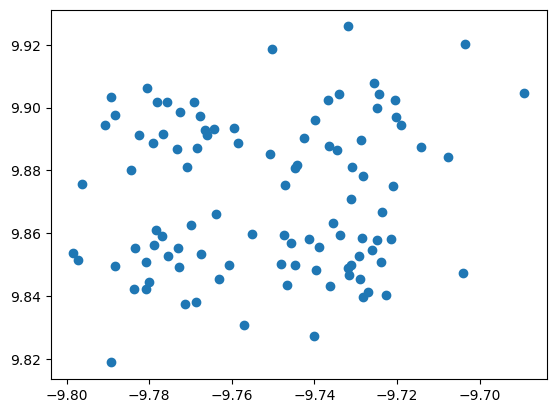

In [72]:
plt.scatter(post_param[:,0], post_param[:,1])
plt.show()

# Next Step: Singular model
+ As a test case of sigular model, we consider about the following model:
$$
p(y|x,a,b) = N(y|a \tanh(bx), 1)
$$
+ When $a=0$ or $b=0$, the model is singular.

## Data Generation

In [129]:
## dimension of input
M = 1

# number of samples
n = 200

data_seed = 20241229
np.random.seed(data_seed)

true_a = 1 #np.random.normal(size=1)
true_b = 2 #np.random.normal(size=1)

train_X = np.random.normal(size=(n,M))
train_Y = true_a * np.tanh(true_b * train_X) + 0.1 * np.random.normal(size=(n,1))
# train_Y = np.random.binomial(1, expit(train_X @ true_w))

## Hyperparameters
+ kernel function: Radial Basis Kernel $\exp(-\|x - y\|^2 / 2h^2)$
+ prior: multivariate distribution $N((a,b)|0, \beta^{-1} I_M)$
+ initial samples: $w \sim q_0(w)$, where $w \in R^{L \times 2}$, $L$ is the number of sample from the approximated posterior

In [130]:
ln_seed = 20241231
np.random.seed(ln_seed)

pri_beta = 1

L = 100
initial_post_param = np.random.normal(size = (L, 2))

h = 1
first_step_size = 0.05

## Learning
+ Change a derivative part of the posterior

In [131]:
n_ite = 5000
post_param = initial_post_param.copy()

disp_cycle = 100

alpha = 0.9
# step_size = 1e-2
jitter = 1e-6
r_t = 0
for ite in range(n_ite):
    dist = pdist(post_param)
    h = np.sqrt(0.5*np.median(dist)**2/np.log(L))
    
    # radial basis kernel is used here
    kernel_post = np.exp(-squareform(dist)/(2*h**2))

    # gradient of kernel function
    dw_kernel_post = (-kernel_post.T @ post_param + kernel_post.sum(axis=0)[:,np.newaxis] * post_param) / (h**2)
    
    # gradient of log posterior
    proc_train_X = train_X.squeeze()[:,np.newaxis]
    proc_train_Y = train_Y.squeeze()[:,np.newaxis]
    residual = proc_train_Y - post_param[:,0][np.newaxis,:] * np.tanh(post_param[:,1][np.newaxis,:] * proc_train_X)
    
    dw_logpy = np.array([
        (residual * (np.tanh(post_param[:,1][np.newaxis,:] * proc_train_X))).sum(axis=0),
        (residual * (post_param[:,0][np.newaxis,:] * proc_train_X / np.cosh(post_param[:,1][np.newaxis,:] * proc_train_X)**2)).sum(axis=0),
    ]).T
    dw_logp = dw_logpy - 1/pri_beta*post_param
    
    # gradient of target functional
    phi_post_param = (kernel_post.T @ dw_logp + dw_kernel_post) / L

    # sample update
    if ite == 0:
        r_t = phi_post_param**2
    else:    
        r_t = alpha * r_t + (1 - alpha) * phi_post_param**2
    
    # step_size = first_step_size / (ite + 1)
    # step_size = first_step_size
    step_size = first_step_size / np.sqrt(r_t + jitter)
    post_param = post_param + step_size * phi_post_param

    if ite % disp_cycle == 0:
        print("ite = {}, post_param = {}, h = {}, step_size = {}".format(ite, post_param[0], h, step_size[0]))
    pass

ite = 0, post_param = [-0.58587376 -0.67252822], h = 0.5536466526065975, step_size = [0.01422049 0.0085066 ]
ite = 100, post_param = [-1.08331365 -1.95903462], h = 1.1305730813342523, step_size = [0.02801598 0.09206699]
ite = 200, post_param = [-1.07855646 -1.90908417], h = 1.1863201652346544, step_size = [0.02720542 0.06468906]
ite = 300, post_param = [-1.07834857 -1.86177703], h = 1.2187697987097963, step_size = [0.02696616 0.04420888]
ite = 400, post_param = [-1.07959474 -1.82711568], h = 1.232987805176942, step_size = [0.02702768 0.03415446]
ite = 500, post_param = [-1.08157222 -1.80399501], h = 1.2476633423848114, step_size = [0.02705791 0.02825134]
ite = 600, post_param = [-1.08439796 -1.78493718], h = 1.2692937429301652, step_size = [0.0269028  0.02342948]
ite = 700, post_param = [-1.08820487 -1.7598683 ], h = 1.277914982797375, step_size = [0.02706934 0.02045732]
ite = 800, post_param = [-1.09034094 -1.74561302], h = 1.311897460449571, step_size = [0.02654465 0.01684857]
ite = 

In [132]:
true_a, true_b

(1, 2)

In [101]:
post_param.mean(axis=0)

array([-0.26931923,  0.32110552])

In [134]:
post_param

array([[ -1.03510051,  -1.59424147],
       [ -0.80138583,  -9.35272361],
       [ -0.82314399,  -6.20789507],
       [ -1.00434305,  -1.52105126],
       [ -0.81635356,  -7.07156068],
       [ -1.00527445,  -1.45481426],
       [  0.94931722,   1.75440948],
       [ -0.86419057,  -2.29007896],
       [  1.07386004,   1.67105072],
       [  1.03441633,   2.03759426],
       [  0.97300327,   2.72092656],
       [  1.16271034,   1.31186407],
       [ -2.08083468,  -0.46320808],
       [  1.15738574,   1.50345663],
       [  1.06446535,   1.7525406 ],
       [  1.2345271 ,   1.11826117],
       [ -1.06547514,  -1.33995049],
       [  1.09037454,   1.92940826],
       [ -0.97958755,  -1.7195231 ],
       [ -1.00868948,  -1.63672743],
       [  1.05231886,   1.75225056],
       [ -6.86416475,  -0.09118473],
       [  0.90001167,   6.14763654],
       [  2.21162553,   0.48684547],
       [ -0.89940223,  -1.66702477],
       [ -5.32519643,  -0.12583266],
       [ -5.32042454,  -0.12570184],
 

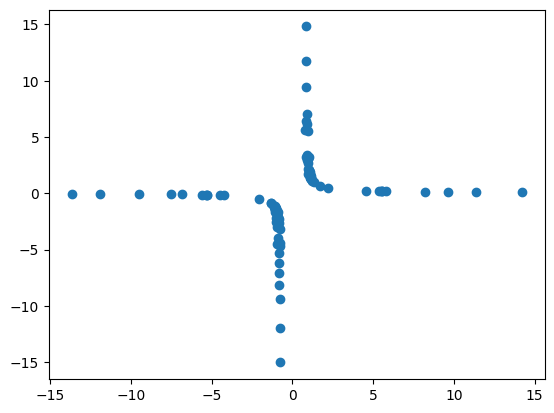

In [133]:
plt.scatter(post_param[:,0], post_param[:,1])
plt.show()

In [49]:
dist = pdist(post_param)

# radial basis kernel is used here
kernel_post = np.exp(-squareform(dist)/(2*h**2))

# gradient of kernel function
dw_kernel_post = (-kernel_post.T @ post_param + kernel_post.sum(axis=0)[:,np.newaxis] * post_param) / (h**2)

# gradient of log posterior
dw_logp = (train_X.sum(axis=0)[np.newaxis,:] - (n + 1/pri_beta)*post_param)

# gradient of target functional
phi_post_param = (kernel_post.T @ dw_logp + dw_kernel_post) / L

In [ ]:
dw_partial_kernel = -2/h * (post_param[np.newaxis,:,:] - post_param[:,np.newaxis,:]) * kernel_post[:,:,np.newaxis]
dwdw_kernel = (2/h * kernel_post[:,:,np.newaxis] * (1+(post_param[np.newaxis,:,:] - post_param[:,np.newaxis,:])**2/h))

# divergence of phi
div_phi = (dw_logp[np.newaxis,:,:] * dw_partial_kernel + dwdw_kernel).sum(axis=2).mean()

In [ ]:
dw_logp_phi = (dw_logp * phi_post_param).sum(axis=1).mean()

stein_discrepancy = dw_logp_phi + div_phi

In [55]:
stein_discrepancy

10.61485416941364